# Mechanisms 1: a bounding test on connection lag

**The question.** Can the hard core's gaps be explained by simple *delay*, an installation put up
before the aerial survey but connected and registered after it?

**How the bound works.** The registry reference is date-matched, meaning it counts only connections
at or before the municipality's imagery date. Any genuinely delayed system therefore lies among the
connections made *after* the survey. The capacity connected between the imagery date and the
registry extraction, which we call the mass in transit, is consequently an **absolute upper bound**
on what delay can account for.

The bound is deliberately generous: it also counts installations genuinely built after the image,
which delay cannot explain by definition. That is the point. If the gap exceeds the mass in transit,
delay cannot explain it even under an assumption chosen to favour delay as far as the data allows.

**A realistic refinement.** Residential connection delays below 36 kVA run to one to three months,
so the share of the transit plausibly attributable to lag is the first k months. Both readings, the
absolute bound and the realistic window, are exported.

**A limit on depth.** The registry extraction dates from 13 October 2025, so units imaged in 2025
have only two to three months of depth. Their absolute bound is truncated, and it is already below
their gap, which is why the truncation does not weaken the conclusion for them.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
import style

RTE_EXTRACT_DATE = pd.Timestamp('2025-10-13')   # date of the registry extraction
K_REALISTIC = 3                                 # realistic lag window, months
K_GRID = [2, 3, 6, 12]                          # windows reported in the export

comparison = gpd.read_file(ROOT / '0_data' / 'postprocess' / 'merge-sources' / paths.COMPARISON_DEPT)
specs_df = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
# Cumulative connected capacity per unit at each cutoff date. This replaces the
# per-installation extract, which is not redistributable: every quantity this
# notebook needs is a difference between two cumulative totals.
cutoffs = pd.read_csv(paths.RTE_CUTOFFS, dtype={'unit': str})
cum = cutoffs.pivot_table(index='unit', columns='cutoff_label', values='kWp_cumulative')


# Cutoff labels in date order, and their dates, per unit, so a blanked cell can
# fall back to a surviving neighbour. 'audit_reference' is excluded: it shares a
# date with 't0' and is the audited value, not a point of the temporal series.
_series = cutoffs[cutoffs.cutoff_label != 'audit_reference'].assign(
    _dt=lambda x: pd.to_datetime(x.cutoff_date))
_seq = {u: list(g.sort_values('_dt').cutoff_label) for u, g in _series.groupby('unit')}
_dates = _series.pivot_table(index='unit', columns='cutoff_label',
                             values='_dt', aggfunc='first')


def cumulative(unit, label, how='widen'):
    """Cumulative connected capacity of ``unit`` at ``label``.

    A cell can be empty for two unrelated reasons, handled differently.

    **Past the extraction date.** Cutoffs beyond 13 October 2025 are empty by
    construction: the registry has nothing to report there, so a unit imaged in
    2025 has no '+6m' value. These cap at the extraction total, which is what the
    original per-installation computation did implicitly by taking
    ``min(cutoff + k months, extraction date)``. The window is truncated, not
    zero.

    **Blanked by disclosure control.** Cutoffs whose increment fell at or below
    the 36 kWp perimeter are removed before release (see
    ``code/0_pipeline/registries/apply_disclosure_control.py``). The series is
    cumulative, so the interval containing a blanked cutoff is not lost, only
    measurable over a wider window: we walk *away from* ``t0`` to the nearest
    surviving cutoff.

    Two fallbacks, because the two things this function is asked for are not the
    same kind of quantity.

    ``how='widen'`` walks *away from* ``t0``, and is what a **window** wants: the
    transit and pre-image masses are differences between two cutoffs, so widening
    inflates them, and a larger mass makes a flagged gap harder to sustain.
    Falling back the other way would shrink the comparison quantity and let flags
    survive too easily. The conservative choice is the one that argues against our
    own conclusion.

    ``how='nearest'`` takes the surviving cutoff closest in time, and is what a
    **level** wants: the dating sweep compares a single reference against a
    credible interval, so there is no direction to be conservative in, only an
    approximation to keep small. Widening a level is simply the wrong estimate --
    on Loir-et-Cher a blanked ``me+0`` sits six days from ``t0`` and thirty-one
    from ``me+1``, and reaching for the month-away value moves the unit across
    its threshold for no reason but the choice of rule.
    """
    v = cum.at[unit, label]
    if not pd.isna(v):
        return v

    seq = _seq[unit]
    if label not in seq:
        return cum.at[unit, 'extraction']

    if how == 'nearest':
        target = _dates.at[unit, label]
        near = [(abs((_dates.at[unit, k] - target).days), cum.at[unit, k])
                for k in seq if not pd.isna(cum.at[unit, k])]
        return min(near)[1] if near else cum.at[unit, 'extraction']

    i, anchor = seq.index(label), seq.index('t0')
    step = 1 if i >= anchor else -1

    j = i + step
    while 0 <= j < len(seq):
        w = cum.at[unit, seq[j]]
        if not pd.isna(w):
            return w
        j += step
    return cum.at[unit, 'extraction']
dates = gpd.read_file(ROOT / '0_data' / 'postprocess' / 'dates' / paths.IMAGERY_DATES,
                       columns=['dpt', 'imagedate'], ignore_geometry=True)
dates['imagedate'] = pd.to_datetime(dates['imagedate'], errors='coerce')
import units
dates['dpt'] = units.to_unit(dates['dpt'])                     # reporting units
cutoff = dates.groupby('dpt')['imagedate'].agg(lambda x: x.mode().iloc[0] if x.notna().any() else pd.NaT)


## 1. The hard core: units flagged unanimously by the battery

In [2]:
SPEC_COLS = ['status_A', 'status_B']  # the core is A and B; C is a sensitivity flag

# The hard core is unanimity across A and B only. Specification C is monotone in
# a single parameter and counts as a sensitivity indicator, not as a third vote.
hard_core = specs_df[(specs_df[SPEC_COLS] == 'below').all(axis=1)]
hc = comparison.merge(hard_core[['dpt']], on='dpt')
print(f"{len(hc)} units in the under-reported hard core")


18 units in the under-reported hard core


## 2. Mass in transit, and the verdicts

Per unit: the imagery vintage, the depth available up to the extraction date, the capacity
connected within each window, and two verdicts, one under the absolute bound and one under the
realistic window.

In [3]:
rows = []
for _, r in hc.iterrows():
    d = r['dpt']
    cut = cutoff.get(d, pd.NaT)
    gap = (r['p_inst_mean'] - r['kWp_rte']) / 1000

    row = {'dpt': d, 'nom': r['nom'],
           'millesime': cut.strftime('%Y-%m') if pd.notna(cut) else None,
           'profondeur_mois': round((RTE_EXTRACT_DATE - cut).days / 30.4, 1) if pd.notna(cut) else np.nan,
           'gap_MWc': round(gap, 2)}
    # Transit over k months = cumulative at t0 + k, minus cumulative at t0.
    for k in K_GRID:
        row[f'transit_k{k}_MWc'] = round((cumulative(d, f'+{k}m') - cum.at[d, 't0']) / 1000, 2)
    m_full = (cum.at[d, 'extraction'] - cum.at[d, 't0']) / 1000
    row['transit_full_MWc'] = round(m_full, 2)
    # Verdicts: can the connection lag account for the gap?
    row['temporal_bound'] = 'possibly_temporal' if gap <= m_full else 'not_temporal'
    row['temporal_k_realistic'] = 'possibly_temporal' if gap <= row[f'transit_k{K_REALISTIC}_MWc'] else 'not_temporal'
    rows.append(row)

lag = pd.DataFrame(rows).sort_values('gap_MWc', ascending=False)
print(f"absolute bound (whole window, maximally generous): "
      f"{(lag['temporal_bound'] == 'not_temporal').sum()}/{len(lag)} units NOT explained by lag")
print(f"realistic window ({K_REALISTIC} months): "
      f"{(lag['temporal_k_realistic'] == 'not_temporal').sum()}/{len(lag)} units NOT explained")
lag


absolute bound (whole window, maximally generous): 12/18 units NOT explained by lag
realistic window (3 months): 18/18 units NOT explained


,dpt,nom,millesime,profondeur_mois,gap_MWc,transit_k2_MWc,transit_k3_MWc,transit_k6_MWc,transit_k12_MWc,transit_full_MWc,temporal_bound,temporal_k_realistic
14,79,Deux-Sèvres,2023-05,28.7,36.01,1.90,2.46,4.88,13.26,30.16,not_temporal,not_temporal
5,24,Dordogne,2024-04,17.8,14.98,1.91,3.01,6.37,11.52,14.38,not_temporal,not_temporal
0,13,Bouches-du-Rhône,2023-06,27.7,12.45,9.64,12.11,19.15,31.71,58.09,possibly_temporal,not_temporal
3,19,Corrèze,2023-08,25.9,11.69,0.78,1.41,2.49,5.02,9.56,not_temporal,not_temporal
13,75PC,Paris + petite couronne,2024-08,13.6,11.17,0.82,1.14,2.37,3.85,3.85,not_temporal,not_temporal
6,28,Eure-et-Loir,2023-05,28.5,10.89,0.58,0.70,1.51,3.30,8.18,not_temporal,not_temporal
15,86,Vienne,2023-05,28.6,10.25,1.03,1.46,3.23,6.28,11.10,possibly_temporal,not_temporal
16,88,Vosges,2025-07,3.3,9.73,0.90,0.90,0.90,0.90,0.90,not_temporal,not_temporal
7,2A,Corse-du-Sud,2024-07,15.1,7.95,0.41,0.76,1.97,1.97,1.97,not_temporal,not_temporal
8,2B,Haute-Corse,2024-07,15.1,7.11,0.53,1.10,1.79,1.79,1.79,not_temporal,not_temporal


## Symmetrising: can timing explain the over-reported units?

The mirror artefact of connection lag. A connection **date is administrative** and can precede the
panels actually going up: the file is registered, the installation follows some weeks later.

The symmetric generous bound asks whether, if *all* the capacity connected in the k months
**before** the survey were still invisible on the image, the registry surplus of the over-reported
units would close.

This channel is markedly less plausible than the downstream one, since installation almost always
precedes connection rather than following it. Three months is therefore *very* generous here, and
running the test anyway is what makes the negative control a control rather than an assertion.

In [4]:
hard_core_above = specs_df[(specs_df[SPEC_COLS] == 'above').all(axis=1)]
hca = comparison.merge(hard_core_above[['dpt']], on='dpt')
rows_a = []
for _, r in hca.iterrows():
    d = r['dpt']
    cut = cutoff.get(d, pd.NaT)
    gap = (r['kWp_rte'] - r['p_inst_mean']) / 1000   # registry surplus, positive for an 'above'
    row = {'dpt': d, 'nom': r['nom'],
           'millesime': cut.strftime('%Y-%m') if pd.notna(cut) else None,
           'gap_above_MWc': round(gap, 2)}
    # Capacity connected in the k months *before* the image: cumulative at t0
    # minus cumulative at t0 - k.
    for k in K_GRID:
        row[f'preimage_k{k}_MWc'] = round((cum.at[d, 't0'] - cumulative(d, f'-{k}m')) / 1000, 2)
    row['temporal_k_realistic'] = ('possibly_temporal'
        if gap <= row[f'preimage_k{K_REALISTIC}_MWc'] else 'not_temporal')
    rows_a.append(row)

lag_above = pd.DataFrame(rows_a).sort_values('gap_above_MWc', ascending=False)
n_not = (lag_above['temporal_k_realistic'] == 'not_temporal').sum()
print(f"over-reported, generous {K_REALISTIC}-month window BEFORE the image: "
      f"{n_not}/{len(lag_above)} units NOT explained by administrative anticipation")
lag_above.to_csv(paths.TEMPORAL_LAG_ABOVE, index=False)
print("wrote temporal_lag_above_departements.csv")
lag_above

over-reported, generous 3-month window BEFORE the image: 7/7 units NOT explained by administrative anticipation
wrote temporal_lag_above_departements.csv


,dpt,nom,millesime,gap_above_MWc,preimage_k2_MWc,preimage_k3_MWc,preimage_k6_MWc,preimage_k12_MWc,temporal_k_realistic
1,31,Haute-Garonne,2025-06,27.19,3.74,5.84,13.13,31.87,not_temporal
4,54,Meurthe-et-Moselle,2025-07,12.50,1.32,1.79,4.01,9.37,not_temporal
5,81,Tarn,2025-06,11.89,1.52,2.23,5.17,12.67,not_temporal
0,27,Eure,2025-06,9.39,0.99,2.16,2.16,5.60,not_temporal
3,50,Manche,2025-04,9.19,1.18,2.53,2.53,6.18,not_temporal
2,37,Indre-et-Loire,2025-06,8.51,0.69,1.12,2.73,6.63,not_temporal
6,89,Yonne,2023-06,4.53,0.54,0.82,1.58,2.72,not_temporal


## 3. Figure et export

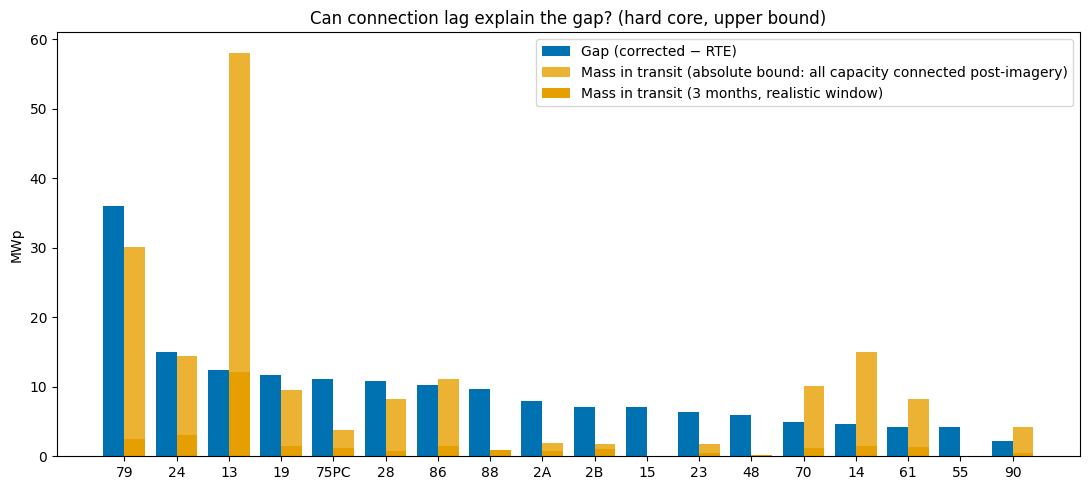

wrote temporal_lag_departements.csv

Under the most generous bound available, connection lag cannot explain the gap for
12 of 18 units; under a realistic 3-month window, for 18 of 18.


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(lag))
ax.bar(x - 0.2, lag['gap_MWc'], width=0.4, color=style.COLOR_SOURCE_OSM, label='Gap (corrected − RTE)')
ax.bar(x + 0.2, lag['transit_full_MWc'], width=0.4, color=style.COLOR_REGISTRY, alpha=0.8,
       label="Mass in transit (absolute bound: all capacity connected post-imagery)")
ax.bar(x + 0.2, lag[f'transit_k{K_REALISTIC}_MWc'], width=0.4, color=style.COLOR_REGISTRY,
       label=f'Mass in transit ({K_REALISTIC} months, realistic window)')
ax.set_xticks(x)
ax.set_xticklabels(lag['dpt'])
ax.set_ylabel('MWp')
ax.set_title("Can connection lag explain the gap? (hard core, upper bound)")
ax.legend()
plt.tight_layout()
fig.savefig(paths.FIGURES / 'mechanisms_temporal_lag_bound.png', dpi=200, bbox_inches='tight')
plt.show()

lag.to_csv(paths.TEMPORAL_LAG, index=False)
print('wrote temporal_lag_departements.csv')
print()
print('Under the most generous bound available, connection lag cannot explain the gap for')
print(f"{(lag['temporal_bound'] == 'not_temporal').sum()} of {len(lag)} units; under a realistic "
      f"{K_REALISTIC}-month window, for "
      f"{(lag['temporal_k_realistic'] == 'not_temporal').sum()} of {len(lag)}.")


## The public registry's annual attribution: does local growth explain its over-reported units?

The public registry, in its truncation-free departmental form, is published annually as a stock at
31 December. Date matching at annual granularity therefore absorbs connections made after the
image, and the expected overshoot is proportional to the **growth of the registry stock during the
imagery year**.

The test regresses the relative gap on that growth rate across the 93 units. It is a prediction
with a sign attached, which is what makes a null result informative rather than merely absent.

units excluded (growth not computable): 2


/sessions/happy-gracious-franklin/tmp/ipykernel_10/104248526.py:18: RuntimeWarning: invalid value encountered in scalar divide
  g = (stock.loc[u, N] - stock.loc[u, N - 1]) / stock.loc[u, N - 1]


n = 91 units | Pearson r = +0.02 (p = 0.8437) | Spearman rho = -0.05 (p = 0.6450)
prediction: strong growth -> registry overshoot -> more NEGATIVE relative gap (r < 0)
median growth of the over-reported units: 25.0% against the rest: 24.9% (Mann-Whitney p = 0.8395)


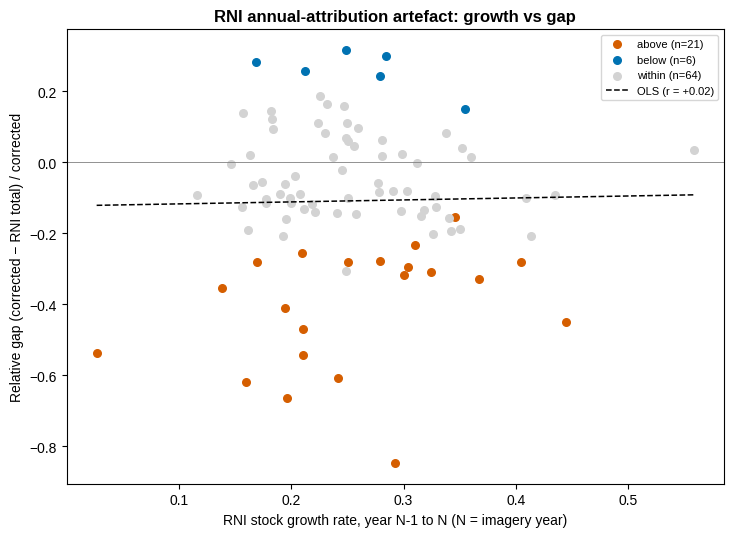

In [6]:
rni = pd.read_csv(paths.RNI, low_memory=False,
                  dtype={'codedepartement': str})
rni['unit'] = units.to_unit(rni['codedepartement'].str.zfill(2))
stock = rni.groupby(['unit', 'year'])['p_inst'].sum().unstack()

rni_agg = pd.read_csv(paths.SPECS_RNI_AGG, dtype={'dpt': str})
rni_agg['ecart_rel'] = (rni_agg.p_inst_mean - rni_agg.kWp_rte) / rni_agg.p_inst_mean  # the reference column is the public registry here

rows = []
for _, r in rni_agg.iterrows():
    u = r.dpt
    cut = cutoff.get(u, pd.NaT)
    if pd.isna(cut) or u not in stock.index:
        continue
    N = cut.year
    if N - 1 not in stock.columns or N not in stock.columns:
        continue
    g = (stock.loc[u, N] - stock.loc[u, N - 1]) / stock.loc[u, N - 1]
    rows.append({'dpt': u, 'ecart_rel': r.ecart_rel, 'growth': g, 'status_A': r.status_A,
                 'above': r.status_A == 'above'})
gr = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=['growth', 'ecart_rel'])
print(f"units excluded (growth not computable): {93 - len(gr)}")
from scipy import stats as _st
r_all, p_all = _st.pearsonr(gr.growth, gr.ecart_rel)
rho, p_rho = _st.spearmanr(gr.growth, gr.ecart_rel)
print(f"n = {len(gr)} units | Pearson r = {r_all:+.2f} (p = {p_all:.4f}) | Spearman rho = {rho:+.2f} (p = {p_rho:.4f})")
print(f"prediction: strong growth -> registry overshoot -> more NEGATIVE relative gap (r < 0)")
print(f"median growth of the over-reported units: {gr.loc[gr.above, 'growth'].median():.1%} "
      f"against the rest: {gr.loc[~gr.above, 'growth'].median():.1%} "
      f"(Mann-Whitney p = {_st.mannwhitneyu(gr.loc[gr.above, 'growth'], gr.loc[~gr.above, 'growth']).pvalue:.4f})")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
COL = {'below': style.OKABE_ITO['blue'], 'within': 'lightgray', 'above': style.OKABE_ITO['vermillion']}
for st_, sub in gr.groupby('status_A'):
    ax.scatter(sub.growth, sub.ecart_rel, s=30, color=COL.get(st_, 'gray'), label=f'{st_} (n={len(sub)})', zorder=2)
b, a = np.polyfit(gr.growth, gr.ecart_rel, 1)
xs = np.linspace(gr.growth.min(), gr.growth.max(), 20)
ax.plot(xs, a + b * xs, ls='--', color='black', lw=1.1, label=f'OLS (r = {r_all:+.2f})')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('RNI stock growth rate, year N-1 to N (N = imagery year)')
ax.set_ylabel('Relative gap (corrected − RNI total) / corrected')
ax.set_title('RNI annual-attribution artefact: growth vs gap', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers as _h
_h.save_fig(fig, 'mechanisms_rni_growth_scatter.png', paths.FIGURES)
plt.show()

### Reading: a null result, and an informative one

**Local growth does not explain the over-reported units**: r = +0.02 (p 0.84), and the median
growth of the over-reported units is indistinguishable from the rest, 25.0% against 24.9%
(Mann-Whitney p 0.84).

The reason is visible in the data. Registry stock growth is **almost uniform across the country**,
around 25% a year. It can therefore explain the *level* of the national overshoot of the
truncation-free registry, roughly −10%, which is what a 31 December attribution against a
mid-year image would produce. It cannot explain the *cross-section*, which unit is flagged and
which is not, because there is barely any cross-sectional variation in it to do the explaining.

Residual heterogeneity would come from the **month of the survey**, the overshoot scaling as
growth times the fraction of the year remaining. That refinement is available but unnecessary
here. The point for the paper is that the annual-attribution artefact is a level phenomenon, not a
differential mechanism, and the over-reported units are not explained by local growth.

## Sensitivity to month-end registry dating

The French case is close to a best case: connection dates to the day, and a cutoff at the exact
imagery date of each municipality. Most registries publish monthly stocks at best, which raises an
obvious question about whether the method transfers.

**The emulation.** For each unit the cutoff becomes the last day of a month, sweeping from three
months before to three months after the month of the survey. Offset zero is the end of the month
containing the flight, which is what a monthly registry would naturally give. The reference is
re-aggregated at each cutoff; the calibration posteriors on the estimate side do not move, so
whatever changes is attributable to the dating alone.

Outputs: status stability, survival of the hard core and of the negative control, the national
surplus, and the relationship between the width of the dating bracket and local growth, which is
the part that transfers to another country.

In [7]:
from pandas.tseries.offsets import MonthEnd

rb_s = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
OFFSETS = range(-3, 4)

rows = []
for _, r in rb_s.iterrows():
    u = r['dpt']
    cut = cutoff.get(u, pd.NaT)
    if pd.isna(cut):
        continue
    row = {'dpt': u, 'ref_exact': r['kWp_rte'], 'p_mean': r['p_inst_mean'],
           'ci99_low': r['p_inst_ci99_low'], 'ci99_high': r['p_inst_ci99_high'],
           'status_base': r['status_A'],
           'hc_below': bool(r['hard_core_below']) if 'hard_core_below' in r else
                       (r['status_A'] == 'below') and (r['status_B'] == 'below'),
           'hc_above': bool(r['hard_core_above']) if 'hard_core_above' in r else
                       (r['status_A'] == 'above') and (r['status_B'] == 'above')}
    # Month-end offsets are pre-computed cutoffs: me-3 .. me+3.
    for o in OFFSETS:
        row[f'ref_m{o}'] = cumulative(u, f'me{o:+d}', how='nearest')   # a level, not a window
    rows.append(row)
sens = pd.DataFrame(rows)

def status_of(ref, lo, hi):
    return np.where(ref < lo, 'below', np.where(ref > hi, 'above', 'within'))

print(f"{'offset':>7} | {'ref natl (MWc)':>14} | {'surplus':>8} | statuts b/w/a | HC below | ctrl above")
res = []
for o in OFFSETS:
    ref = sens[f'ref_m{o}']
    st = status_of(ref, sens.ci99_low, sens.ci99_high)
    natl_ref = ref.sum() / 1e3
    surplus = 100 * (sens.p_mean.sum() - ref.sum()) / ref.sum()
    hc_surv = int(((st == 'below') & sens.hc_below).sum())
    na_surv = int(((st == 'above') & sens.hc_above).sum())
    unchanged = (st == sens.status_base).mean()
    res.append({'offset_months': o, 'ref_national_MWc': round(natl_ref, 1),
                'surplus_pct': round(surplus, 2), 'n_below': int((st == 'below').sum()),
                'n_within': int((st == 'within').sum()), 'n_above': int((st == 'above').sum()),
                'hc_below_survive': hc_surv, 'ctrl_above_survive': na_surv,
                'share_status_unchanged': round(unchanged, 3)})
    print(f"{o:>+7} | {natl_ref:>14,.0f} | {surplus:>+7.2f}% | "
          f"{int((st=='below').sum()):>2}/{int((st=='within').sum()):>2}/{int((st=='above').sum()):>2}"
          f"        | {hc_surv:>2}/{int(sens.hc_below.sum())}   | {na_surv}/{int(sens.hc_above.sum())}")
sens_out = pd.DataFrame(res)
sens_out.to_csv(paths.TEMPORAL_SENSITIVITY, index=False)
print("\nEcrit : temporal_sensitivity_departements.csv")

 offset | ref natl (MWc) |  surplus | statuts b/w/a | HC below | ctrl above
     -3 |          3,717 |   +8.50% | 31/55/ 7        | 18/18   | 7/7
     -2 |          3,791 |   +6.38% | 29/57/ 7        | 18/18   | 7/7
     -1 |          3,870 |   +4.22% | 26/59/ 8        | 18/18   | 7/7
     +0 |          3,951 |   +2.07% | 21/61/11        | 16/18   | 7/7
     +1 |          4,030 |   +0.06% | 17/63/13        | 14/18   | 7/7
     +2 |          4,103 |   -1.72% | 17/63/13        | 14/18   | 7/7
     +3 |          4,163 |   -3.13% | 15/61/17        | 14/18   | 7/7

Ecrit : temporal_sensitivity_departements.csv


bracket width (+/-3 months): median 11.5%, max 37.4%
width against six-month growth: r = +0.998 (p = 3.29e-115). Mechanical, and this is the rule that transfers.


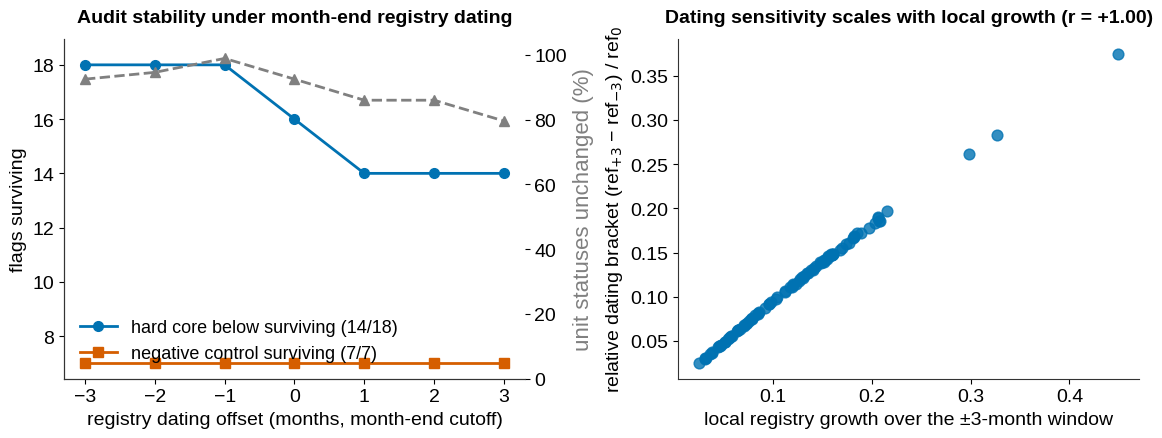

In [8]:
# The transferable relationship: bracket width against local growth
sens['bracket_rel'] = (sens['ref_m3'] - sens['ref_m-3']) / sens['ref_m0']
sens['growth_6m'] = (sens['ref_m3'] - sens['ref_m-3']) / sens['ref_m-3']   # growth over six months

from scipy import stats as _st

ok = sens[['bracket_rel', 'growth_6m']].replace([np.inf, -np.inf], np.nan).dropna().index

r_, p_ = _st.pearsonr(
    sens.loc[ok, 'growth_6m'],
    sens.loc[ok, 'bracket_rel']
)

print(f"bracket width (+/-3 months): median {sens.bracket_rel.median():.1%}, max {sens.bracket_rel.max():.1%}")
print(f"width against six-month growth: r = {r_:+.3f} (p = {p_:.2e}). Mechanical, and this is the rule that transfers.")


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))


# ---------------------------------------------------------
# Plot 1
# ---------------------------------------------------------
ax = axes[0]

ax.plot(
    sens_out.offset_months,
    sens_out.hc_below_survive,
    'o-',
    color=style.OKABE_ITO['blue'],
    label=f'hard core below surviving (14/{int(sens.hc_below.sum())})',
    markersize=7,
    linewidth=2
)

ax.plot(
    sens_out.offset_months,
    sens_out.ctrl_above_survive,
    's-',
    color=style.OKABE_ITO['vermillion'],
    label=f'negative control surviving (7/{int(sens.hc_above.sum())})',
    markersize=7,
    linewidth=2
)

ax.plot(
    sens_out.offset_months,
    93 * sens_out.share_status_unchanged / 5,
    alpha=0
)

ax2 = ax.twinx()

ax2.plot(
    sens_out.offset_months,
    100 * sens_out.share_status_unchanged,
    '^--',
    color='gray',
    linewidth=2,
    markersize=7,
    label='unit statuses unchanged (%)'
)

ax2.set_ylabel(
    'unit statuses unchanged (%)',
    color='gray',
    fontsize=16
)

ax2.set_ylim(0, 105)

ax.set_xlabel(
    'registry dating offset (months, month-end cutoff)',
    fontsize=14
)

ax.set_ylabel(
    'flags surviving',
    fontsize=14
)

ax.set_title(
    'Audit stability under month-end registry dating',
    fontweight='bold',
    fontsize=14,
    pad=12
)

ax.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax.legend(
    fontsize=13,
    loc='lower left'
)


# ---------------------------------------------------------
# Plot 2
# ---------------------------------------------------------
ax = axes[1]

ax.scatter(
    sens.loc[ok, 'growth_6m'],
    sens.loc[ok, 'bracket_rel'],
    s=60,
    color=style.OKABE_ITO['blue'],
    alpha=0.8
)

ax.set_xlabel(
    'local registry growth over the ±3-month window',
    fontsize=14
)

ax.set_ylabel(
    'relative dating bracket (ref$_{+3}$ − ref$_{-3}$) / ref$_0$',
    fontsize=14
)

ax.set_title(
    f'Dating sensitivity scales with local growth (r = {r_:+.2f})',
    fontweight='bold',
    fontsize=14,
    pad=12
)

ax.tick_params(
    axis='both',
    labelsize=14
)


plt.tight_layout()

sys.path.insert(
    0,
    str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src')
)

import helpers as _hh

_hh.save_fig(
    fig,
    'mechanisms_temporal_sensitivity.pdf',
    paths.FIGURES
)

plt.show()

## 4. An ad hoc test: does fragmented reporting catch up by year end?

**The question.** For units served almost entirely by a local distributor, at least 90% of
municipalities, does the capacity deficit close if the registry is extended to the **close of the
imagery year**? Put differently: does fragmentation produce a *delay* in reporting, absorbed at
year end and possibly in batches, or a *loss* of information?

**The criterion.** The cumulative registry capacity is compared against the **lower bound of the
99% interval**, not against the corrected mean. Entering the interval is therefore the threshold
most favourable to the registry, which is the right way round for a test meant to give delay every
chance.

Ad hoc, and nothing else in the analysis depends on it.

In [9]:
ELD_UNITS = ['2A', '2B', '79', '86']          # at least 90% of municipalities ELD-served
rb_e = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})

rows = []
for u in ELD_UNITS:
    r = rb_e[rb_e.dpt == u].iloc[0]
    base = cum.at[u, 't0']                      # date-matched registry
    eoy = cumulative(u, 'eoy')                  # registry at 31 December of the imagery year
    got = eoy - base
    need = r.p_inst_ci99_low - base             # what it takes to enter the interval
    rows.append({'dpt': u, 'nom': r.nom,
                 'date_matched_registry_MWp': round(base / 1e3, 2),
                 'ci99_low_MWp': round(r.p_inst_ci99_low / 1e3, 2),
                 'corrected_mean_MWp': round(r.p_inst_mean / 1e3, 2),
                 'needed_MWp': round(need / 1e3, 2),
                 'connected_to_year_end_MWp': round(got / 1e3, 2),
                 'coverage_of_the_need': round(got / need, 2) if need > 0 else np.nan,
                 'verdict': 'enters the CI' if eoy >= r.p_inst_ci99_low else 'stays below the CI',
                 'residual_deficit_MWp': round((need - got) / 1e3, 2) if need > got else 0.0})

eld_lag = pd.DataFrame(rows)
eld_lag.to_csv(paths.TEMPORAL_LAG_ELD, index=False)
print(eld_lag.to_string(index=False))
n_in = (eld_lag.verdict == 'enters the CI').sum()
print(f"\nVERDICT: {n_in}/{len(eld_lag)} heavily ELD-served unit(s) see their registry capacity")
print("enter the 99% interval before the close of the imagery year.")


dpt          nom  date_matched_registry_MWp  ci99_low_MWp  corrected_mean_MWp  needed_MWp  connected_to_year_end_MWp  coverage_of_the_need            verdict  residual_deficit_MWp
 2A Corse-du-Sud                       5.12         10.28               13.08        5.16                       1.97                  0.38 stays below the CI                  3.20
 2B  Haute-Corse                       5.51         10.47               12.67        4.96                       1.79                  0.36 stays below the CI                  3.16
 79  Deux-Sèvres                      31.79         50.69               67.66       18.90                       5.58                  0.30 stays below the CI                 13.32
 86       Vienne                      26.92         31.05               37.07        4.13                       3.62                  0.88 stays below the CI                  0.51

VERDICT: 0/4 heavily ELD-served unit(s) see their registry capacity
enter the 99% interval before t

> **This figure does not run from the released data.**
>
> It plots the *monthly* build-up of registry capacity between the imagery date
> and the end of the year, which needs a connection date per installation. The
> released aggregates carry the two endpoints, which is enough for the verdict
> table above but not for the monthly increments.
>
> The increments are what would reveal batch reporting, so the figure is kept
> here as a record of what was looked at. It is not a published figure, and
> nothing else in the analysis depends on it.


In [10]:
# The monthly build-up needs a connection date per installation, which the release
# does not carry: the aggregates hold the two endpoints, enough for the verdict
# table above but not for the increments. Skipped with a message rather than
# raising, so the notebook runs end to end.
MONTHLY_OK = 'series' in dir() and bool(series)
if not MONTHLY_OK:
    print("SKIPPED: the monthly catch-up figure needs the per-installation registry extract.")
    print("The verdict table above is computed from the released cutoff aggregates.")

if MONTHLY_OK:
    fig, axes = plt.subplots(len(ELD_UNITS), 1, figsize=(9, 2.9 * len(ELD_UNITS)), sharex=False)
    C_CUM, C_BAR = style.OKABE_ITO['blue'], '#b9b9b9'
    C_BAND, C_MEAN = style.OKABE_ITO['orange'], style.OKABE_ITO['vermillion']

    for ax, u in zip(np.atleast_1d(axes), ELD_UNITS):
        s = series[u]
        r = eld_lag[eld_lag.dpt == u].iloc[0]
        # bande IC99 + moyenne redressee (en MWc)
        ax.axhspan(s['lo'] / 1e3, s['hi'] / 1e3, color=C_BAND, alpha=0.18, zorder=1,
                   label='99% credible interval (corrected estimate)')
        ax.axhline(s['mean'] / 1e3, color=C_MEAN, lw=1.4, zorder=2, label='corrected mean')
        ax.axhline(s['lo'] / 1e3, color=C_BAND, lw=1.2, ls='--', zorder=2, label='99% CI lower bound')
        # Monthly increments on a secondary axis: this is where batch reporting would show
        ax2 = ax.twinx()
        ax2.bar(s['monthly'].index, s['monthly'].values / 1e3, width=20, color=C_BAR, alpha=0.75, zorder=0)
        ax2.set_ylabel('monthly additions (MWp)', fontsize=8, color='#777777')
        ax2.tick_params(axis='y', labelsize=7, colors='#777777')
        ax2.set_ylim(0, max(s['monthly'].max() / 1e3 * 4, 0.1))
        # Cumulative registry capacity
        x = [s['t0']] + list(s['cum'].index)
        y = [s['base'] / 1e3] + list(s['cum'].values / 1e3)
        ax.plot(x, y, color=C_CUM, lw=2.2, marker='o', ms=3.5, zorder=3,
                label='registry capacity, cumulative')
        if r.date_franchissement is not None:
            ax.axvline(pd.Timestamp(r.date_franchissement), color='black', ls=':', lw=1.2, zorder=3)
        ax.set_xlim(s['t0'] - pd.Timedelta(days=8), s['eoy'] + pd.Timedelta(days=8))
        ax.set_ylabel('installed capacity (MWp)', fontsize=8)
        ax.set_title(f"{r.nom} ({u}) --- imagery {r.millesime}, {r.mois_dispo} months to year end "
                     f"| {r.verdict}"
                     f" (needs {r.a_trouver_MWc:.1f}, gets {r.raccorde_jusqu_au_3112_MWc:.1f} MWp)",
                     fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=8)
        ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)

    np.atleast_1d(axes)[0].legend(fontsize=7.5, loc='lower right', framealpha=0.95)
    np.atleast_1d(axes)[-1].set_xlabel('date (from median imagery acquisition to 31 December of the same year)',
                                       fontsize=8.5)
    plt.tight_layout()
    sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
    import helpers as _h
    _h.save_fig(fig, 'mechanisms_eld_temporal_catchup.png', paths.FIGURES)
    plt.show()


SKIPPED: the monthly catch-up figure needs the per-installation registry extract.
The verdict table above is computed from the released cutoff aggregates.
